# PMFRG example usecase

This is a small example of how the pmfrg is used in practise. The system considered is a pyrochlore lattice with anisotropic nearest and next-nearest neighbor interactions. The structure factor and the correlation length over temperature are calculated

## Needed packages

To get a minimal example to run, the PMFRG_xyz.jl script as well as the SpinFRGLatties package suffices. DiffEqCallbacks can be included if you want to modify the data struct that is outputted (for example if you want to also extract the full vertex functions, the self energy, the free energy etc.). OrdinaryDiffEq is needed if you want the ODE solver to use a more specific solver (like DP5(), Tsit5() etc.). PMFRGEvaluation is needed to extract the correlation length and calculate fourier transforms. FRGLatticePlotting is needed in order to visualize the lattice

## Installation - for those who haven't done this before

Installing the general purpose packages needed for this example can be done in this way:

In [1]:
using Pkg
Pkg.activate(".")


Pkg.add(["DiffEqCallbacks","JLD2","CairoMakie"])

  Activating project at `~/work/PMFRG/pmfrg_xyz/examples`
     Project No packages added to or removed from `~/work/PMFRG/pmfrg_xyz/examples/Project.toml`
    Manifest No packages added to or removed from `~/work/PMFRG/pmfrg_xyz/examples/Manifest.toml`


**TODO**: These are additional packages that are not needed directly, and should not be needed once PMFRG is installed properly (I think)

In [2]:
Pkg.add(["RecursiveArrayTools","StructArrays","OrdinaryDiffEqLowOrderRK","Unroll","MuladdMacro","FastBroadcast"])

     Project No packages added to or removed from `~/work/PMFRG/pmfrg_xyz/examples/Project.toml`
    Manifest No packages added to or removed from `~/work/PMFRG/pmfrg_xyz/examples/Manifest.toml`


We will also use a few packages from the PMFRG ecosystem. The best way to access those is to add the Julia PMFRG registry:

In [3]:
Pkg.Registry.add(url="https://github.com/PMFRG/JuliaPMFRGRegistry.git")

     Cloning registry from "https://github.com/PMFRG/JuliaPMFRGRegistry.git"
Registry `JuliaPMFRG` already exists in `~/.julia/registries/JuliaPMFRG`.


Then we can add the packages to our environment:

In [4]:
Pkg.add(["SpinFRGLattices","PMFRGEvaluation","FRGLatticePlotting"])

     Project No packages added to or removed from `~/work/PMFRG/pmfrg_xyz/examples/Project.toml`
    Manifest No packages added to or removed from `~/work/PMFRG/pmfrg_xyz/examples/Manifest.toml`


**TODO**: This will just be `Pkg.add["PMFRG"]` and will be in the previous cell.

In [5]:
include("../src/PMFRG_xyz.jl")

Main.PMFRG_xyz

## Using the packages

If you have already installed the packages, you can proceed with loading them

In [6]:


##using SpinFRGLattices
#using SpinFRGLattices.Pyrochlore
#using DiffEqCallbacks
#using OrdinaryDiffEq
#using PMFRGEvaluation
#using FRGLatticePlotting

#using JLD2

#using CairoMakie

## System Parameters

NLen Maximum correlation lenght. Site pairs with distance greater than NLen will be ignored

In [7]:
NLen = 6

6

Strength and anisotropy of nearest and next-nearest neighbor interactions

In [8]:
J1_strength = 1.0
J2_strength = 0.2 

J1_couplings = [1.0, 0.8, -0.2]
J2_couplings = [0.0, -0.2, 2.0]

3-element Vector{Float64}:
  0.0
 -0.2
  2.0

The System objects contains all the relevant lattice information needed for the pmfrg. This includes the site pairs, as well as the multiplicity with which they appear in the flow equations. Most of these parameters are irrelevant for practical use and are automatically calculated when implementing a lattice using the SpinFRGLattices package

You can plot the System to check whether the implementation is done correctly. The FRGLatticePlotting package can visualize the different sublattices and their respective couplings as well as the symmetry inequivalent part of the lattice

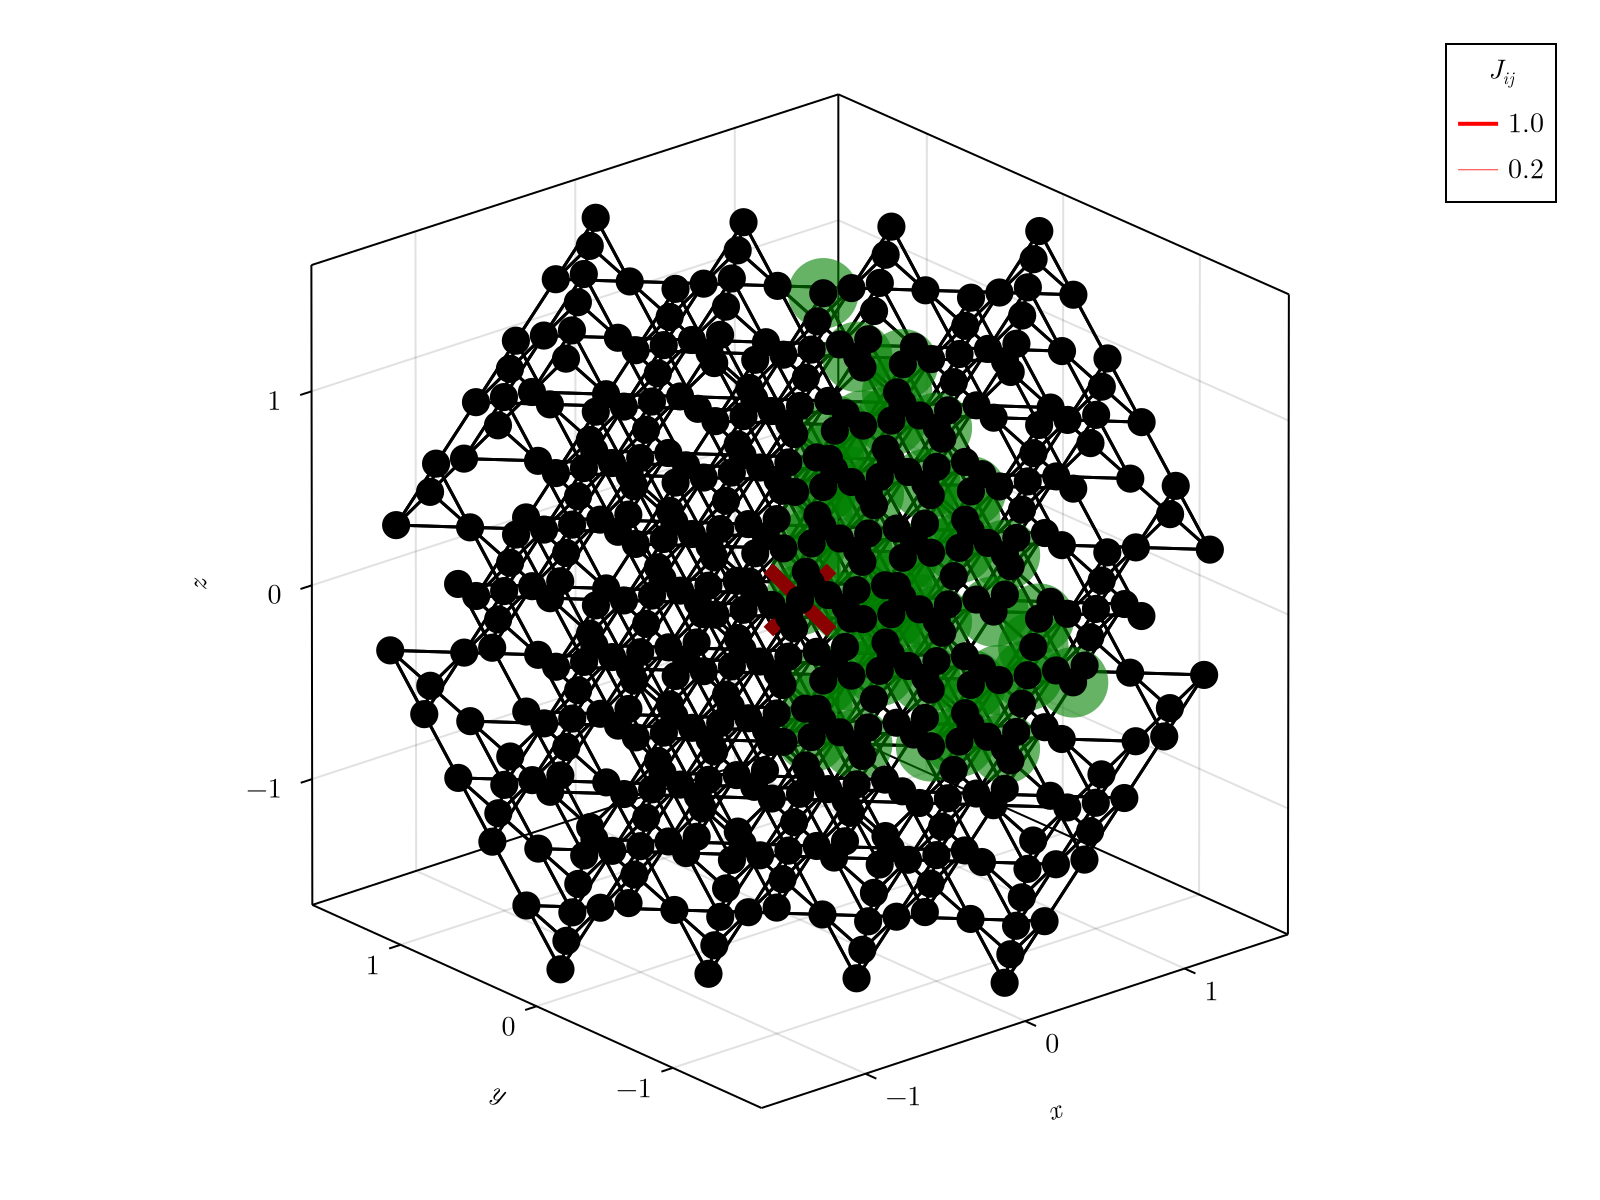

In [9]:
import SpinFRGLattices: Pyrochlore
import FRGLatticePlotting: plotSystem

System = Pyrochlore.getPyrochlore(NLen, [J1_strength, J2_strength])
fig = plotSystem(System, Pyrochlore.Basis)

As a next step the anisotropy of the couplings has to be specified The anisotropy is then multiplied against the couplings J = J_strength .* anisotropy. The Js represent the initial conditions For the flow of the vertex functions.

In [10]:
anisotropy = zeros(System.Npairs, 3)

for n in 1:System.Npairs
    if(System.couplings[n] == J1_strength)
        anisotropy[n, :] = J1_couplings
    elseif(System.couplings[n] == J2_strength)
        anisotropy[n, :] = J2_couplings
    end
end

The `PMFRG_xyz.Params` data structure contains the configuration on the simulation.
Main aruments are:
- the `System` data structure;
- the number of Mazubara frequencies `N`;
- the minimum and maximum temperature;
- the accuracy of the ODE solver.

The simulation resolution is mainly improved by scaling NLen and the number of Mazubara frequencies.

In [11]:
import .PMFRG_xyz: Params # TODO: this will just be using PMFRG
Par = PMFRG_xyz.Params(
    System,
    N = 6,
    temp_max = 100.0,
    temp_min = 0.1,
    accuracy = 1e-4
);

The flow returns a sol object from the ODE solver, as well as a saved_values struct containing the logarithmic temperatures saved_values.t as well as the spin-spin correlations saved_values.saveval

In [12]:
import OrdinaryDiffEqLowOrderRK: DP5
import JLD2
import .PMFRG_xzy
# TODO: This function should not output so much to screen
sol, saved_values = PMFRG_xyz.SolveFRG(Par, anisotropy; method=DP5())
JLD2.save_object("pyrochlore_NLen=$(NLen)_N=6.jld2", [(saved_values.saveval[n], exp(saved_values.t[n])) for n in eachindex(saved_values.t)]);

Allocate Setup


Solving FRG


Without further specification, the pmfrg code only saves the (mazubara-)frequency dependent spin-spin correlations. You can modify this by passing your own custum struct

In [13]:
struct ObservablesDynamic{T}
    Chi_x::Array{T,2}
    Chi_y::Array{T,2}
    Chi_z::Array{T,2}
end

function save_dynamic_chis(State, t, Par)
    chi_x = PMFRG_xyz.getChi_x(State, exp(t), Par, Par.NumericalParams.N)
    chi_y = PMFRG_xyz.getChi_y(State, exp(t), Par, Par.NumericalParams.N)
    chi_z = PMFRG_xyz.getChi_z(State, exp(t), Par, Par.NumericalParams.N)
    return ObservablesDynamic(copy(chi_x), copy(chi_y), copy(chi_z))
end

import DiffEqCallbacks

sol, saved_values = PMFRG_xyz.SolveFRG(
        Par, anisotropy,
        DiffEqCallbacks.SavedValues(PMFRG_xyz._getFloatType(Par), ObservablesDynamic{PMFRG_xyz._getFloatType(Par)}), 
        (State, t, integrator) -> save_dynamic_chis(State, t, Par)
    )
JLD2.save_object("pyrochlore_NLen=$(NLen)_N=6.jld2", [(saved_values.saveval[n], exp(saved_values.t[n])) for n in eachindex(saved_values.t)])

Allocate Setup
Solving FRG


## Evaluation

In [14]:
data = JLD2.load_object("pyrochlore_NLen=6_N=6.jld2");

To plot the structure factor it is sufficient to Fourier transform the spin-spin correlation function. This is most easily done using the `PMFRGEvaluation` package which is built to be used in conjunction with `SpinFRGLattices`:

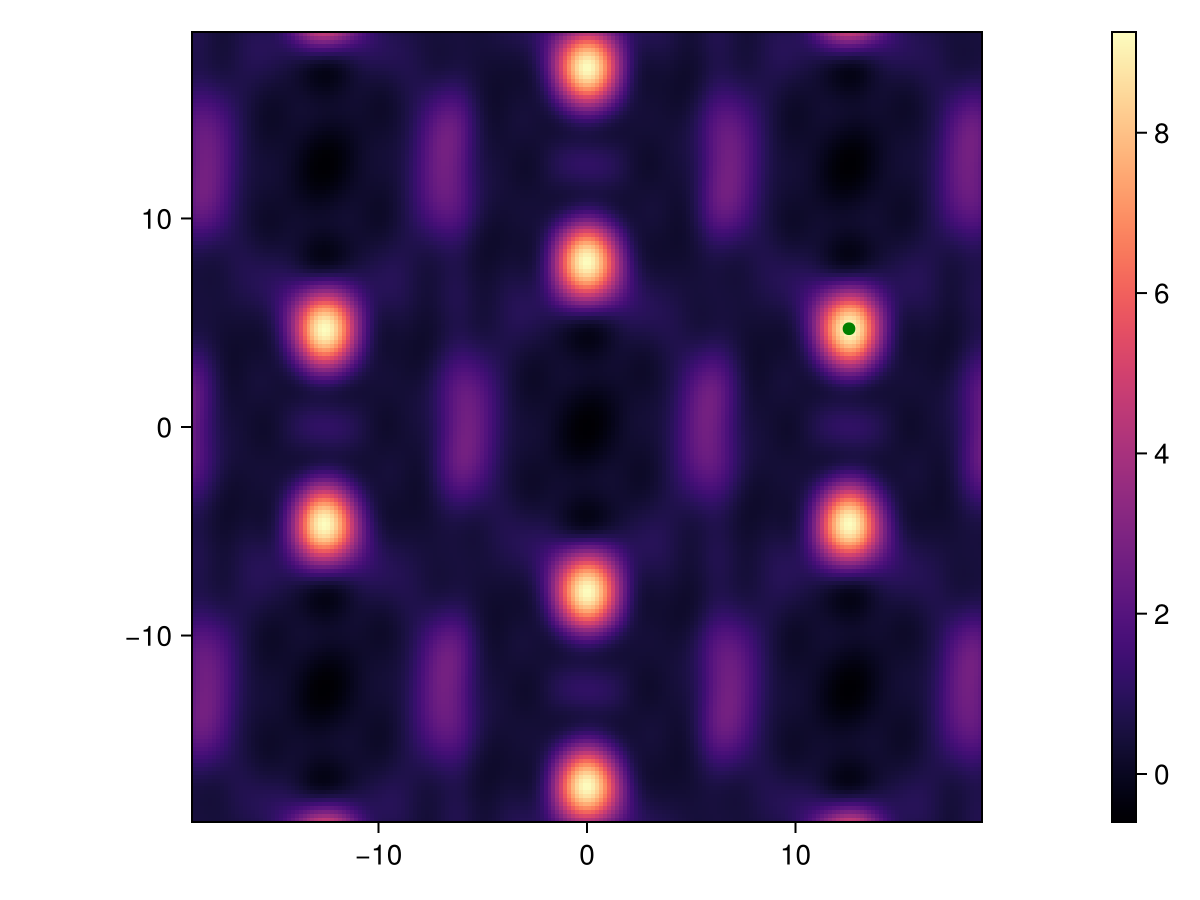

In [15]:
import PMFRGEvaluation: LatticeInfo, getFourier
using CairoMakie
let
    data=JLD2.load_object("pyrochlore_NLen=6_N=6.jld2")
    n = 600

    chi_R = data[n][1].Chi_z[:, 1]

    System = Pyrochlore.getPyrochlore(6, [J1_strength, J2_strength])
    Lattice = LatticeInfo(System, Pyrochlore)

    ChiFunc = getFourier(chi_R, Lattice)

    k = LinRange(-6π, 6π, 200)
    
    a = sqrt(2/3)
    b = sqrt(1/2)
    chi_k = [ChiFunc(x, x, y) for x in k, y in k]

    fig, ax, hm = heatmap(k,k,chi_k,axis = (;aspect = 1),colormap = :magma)
    scatter!(ax, [4π], [3π/2], color=:green)
    Colorbar(fig[1,2],hm)
    display("image/png", fig)
end

From the fourier transformed correlations you can calculate the correlation length. This is done internally by fitting a lorentz-curve onto the order-peak. The correlation length is then extracted from its width

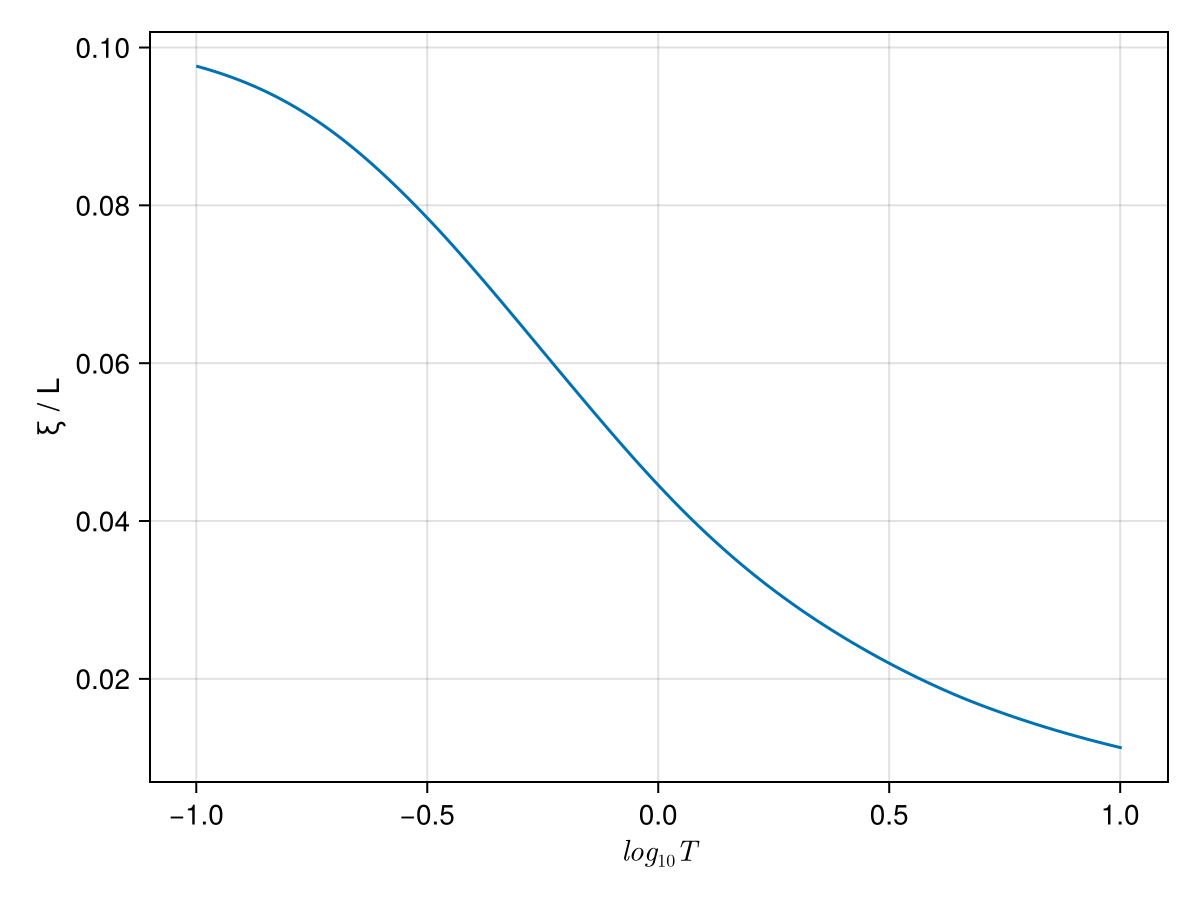

In [16]:
import PMFRGEvaluation: maxCorrelationLength, SA
offset = 200
System = Pyrochlore.getPyrochlore(NLen, [J1_strength, J2_strength])
Lattice = LatticeInfo(System, Pyrochlore)

xi = []
for nT in eachindex(data)
    T = data[nT][2]
    chi_R = data[nT][1].Chi_z[:, 1]
    chi_F = getFourier(chi_R, Lattice)

    append!(xi, maxCorrelationLength(SA[4π, 4π, 3π/2], chi_F, NLen) / NLen)
end

let
    fig = Figure()
    ax = Axis(fig[1,1], xlabel = L"log_{10} T", ylabel = "ξ / L")
    ax.xlabelsize = 15.0
    ax.ylabelsize = 15.0

    T = getindex.(data, 2)
    lines!(ax, log10.(T[offset:end]), xi[offset:end])

    # axislegend(ax)
    display("image/png", fig)
end